In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import random
from scipy.spatial.distance import cdist


In [2]:
def gaussian_kernel(X, Y, sigma):
    """Gaussian kernel: K(x,y) = exp(-||x-y||^2 / 2*sigma^2)."""
    X_sq = np.sum(X ** 2, axis=1).reshape(-1, 1)
    Y_sq = np.sum(Y ** 2, axis=1).reshape(1, -1)
    dist_sq = np.maximum(X_sq + Y_sq - 2 * X @ Y.T, 0.0)  # clamp tiny negatives from roundoff
    return np.exp(-dist_sq / (2 * sigma ** 2))

def auto_select_sigma(X, multiplier=5):
    """sigma = multiplier * mean(nearest-neighbor distances). Training set only."""
    D = cdist(X, X, metric='euclidean')
    np.fill_diagonal(D, np.inf)
    return multiplier * np.mean(np.min(D, axis=1))

def pca_fit_project(X_tr, X_te):
    """PCA via the N x N Gram trick. Returns full-rank projections (Ztr, Zte)."""
    mf = X_tr.mean(axis=0); Xc = X_tr - mf; Xe = X_te - mf; n = Xc.shape[0]
    cov = (Xc @ Xc.T) / (n - 1)
    ev, es = np.linalg.eigh(cov); es = es[:, np.argsort(ev)[::-1]]
    W = Xc.T @ es
    W = W / np.linalg.norm(W, axis=0)
    return Xc @ W, Xe @ W

def kpca_fit_project(X_tr, X_te, sigma):
    """Gaussian KPCA: centered Gram matrix + out-of-sample centering with the
    training kernel statistics. Returns projections (Ztr, Zte)."""
    K_tr = gaussian_kernel(X_tr, X_tr, sigma); N = K_tr.shape[0]
    one_N = np.ones((N, N)) / N
    K_c = K_tr - one_N @ K_tr - K_tr @ one_N + one_N @ K_tr @ one_N
    ev, ec = np.linalg.eigh(K_c)
    idx = np.argsort(ev)[::-1]; ev = ev[idx]; ec = ec[:, idx]
    pos = ev > 1e-10; ev = ev[pos]; ec = ec[:, pos]
    al = ec / np.sqrt(ev)
    Ztr = K_c @ al
    K_te = gaussian_kernel(X_te, X_tr, sigma); N_te = X_te.shape[0]
    one_te = np.ones((N_te, N)) / N
    K_te_c = K_te - one_te @ K_tr - K_te @ one_N + one_te @ K_tr @ one_N
    return Ztr, K_te_c @ al

def acc_at_k(Ztr, y_tr, Zte, y_te, k):
    """1-NN classification accuracy (%) using the first k projected components."""
    d = cdist(Zte[:, :k], Ztr[:, :k], metric='euclidean')
    return np.mean(y_tr[np.argmin(d, axis=1)] == y_te) * 100


### PCA vs KPCA on Yale Faces

We first compare PCA and KPCA on the Yale Faces dataset (15 subjects, 11 images each). To avoid the noise of a single tiny split, every image not used for training becomes a test image (90 test images at `n_train=5`) and every result is averaged over **20 random splits**, reported as mean ± std. This serves as a baseline before the larger Extended Yale B dataset.

In [3]:
# Load the small Yale Faces dataset

def load_yale_faces(path):
    persons = {}
    for folder in sorted(os.listdir(path)):
        fp = os.path.join(path, folder)
        if os.path.isdir(fp):
            imgs = []
            for f in sorted(os.listdir(fp)):
                ffp = os.path.join(fp, f)
                if os.path.isfile(ffp):
                    try:
                        imgs.append(np.array(Image.open(ffp), dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_yale(persons, n_train, seed=42, test_all=True):
    """Train/test split. With test_all=True every image not used for training
    becomes a test image (e.g. 6 test/person at n_train=5), giving a much larger
    and less noisy test set than the previous 1-image-per-person scheme."""
    random.seed(seed)
    tr_i, tr_l, te_i, te_l = [], [], [], []
    for label, imgs in persons.items():
        idx = list(range(len(imgs)))
        random.shuffle(idx)
        for i in idx[:n_train]:
            tr_i.append(imgs[i]); tr_l.append(label)
        rest = idx[n_train:] if test_all else [random.choice(idx[n_train:])]
        for i in rest:
            te_i.append(imgs[i]); te_l.append(label)
    return (np.array([i.flatten() for i in tr_i]), np.array(tr_l),
            np.array([i.flatten() for i in te_i]), np.array(te_l))

persons_yale = load_yale_faces("Datasets/yalefaces")
print(f"Yale Faces: {len(persons_yale)} subjects, {len(next(iter(persons_yale.values())))} images each")
print(f"Image size: {next(iter(persons_yale.values()))[0].shape}")


Yale Faces: 15 subjects, 11 images each
Image size: (243, 320)


Test images/split = 90,  mean sigma (5x) = 47430,  seeds = 20
KPCA peak: 75.72% ± 3.01 at k=61
PCA  peak: 75.78% ± 3.01 at k=63


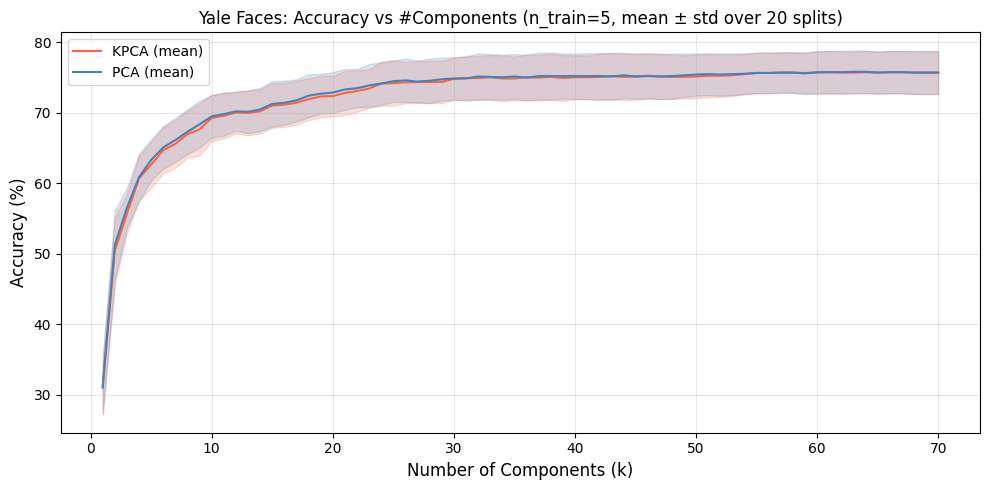

In [4]:
# ── Yale Faces (n_train=5): accuracy vs #components over 20 random splits ──────
# Every image not used for training is a test image (90 test imgs/split), and we
# average over 20 seeds -> mean ± std instead of one noisy 15-image split.
SEEDS = list(range(20))
kpca_curves, pca_curves, sigmas = [], [], []
for s in SEEDS:
    Xtr, ytr, Xte, yte = split_yale(persons_yale, n_train=5, seed=s)
    sig = auto_select_sigma(Xtr, multiplier=5); sigmas.append(sig)
    Ztr_s, Zte_s = kpca_fit_project(Xtr, Xte, sig)
    Ptr_s, Pte_s = pca_fit_project(Xtr, Xte)
    kpca_curves.append([acc_at_k(Ztr_s, ytr, Zte_s, yte, k) for k in range(1, Ztr_s.shape[1] + 1)])
    pca_curves.append([acc_at_k(Ptr_s, ytr, Pte_s, yte, k) for k in range(1, Ptr_s.shape[1] + 1)])

kmax = min(min(map(len, kpca_curves)), min(map(len, pca_curves)))  # common #components
kp = np.array([c[:kmax] for c in kpca_curves]); pc = np.array([c[:kmax] for c in pca_curves])
ks = np.arange(1, kmax + 1)
kp_m, kp_s, pc_m, pc_s = kp.mean(0), kp.std(0), pc.mean(0), pc.std(0)
print(f"Test images/split = {len(yte)},  mean sigma (5x) = {np.mean(sigmas):.0f},  seeds = {len(SEEDS)}")
print(f"KPCA peak: {kp_m.max():.2f}% ± {kp_s[kp_m.argmax()]:.2f} at k={ks[kp_m.argmax()]}")
print(f"PCA  peak: {pc_m.max():.2f}% ± {pc_s[pc_m.argmax()]:.2f} at k={ks[pc_m.argmax()]}")

plt.figure(figsize=(10, 5))
plt.plot(ks, kp_m, '-', color='tomato', label='KPCA (mean)')
plt.fill_between(ks, kp_m - kp_s, kp_m + kp_s, color='tomato', alpha=0.2)
plt.plot(ks, pc_m, '-', color='steelblue', label='PCA (mean)')
plt.fill_between(ks, pc_m - pc_s, pc_m + pc_s, color='steelblue', alpha=0.2)
plt.xlabel("Number of Components (k)", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Yale Faces: Accuracy vs #Components (n_train=5, mean ± std over 20 splits)", fontsize=12)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("figures/kpca_968ecc69_0.png", dpi=110, bbox_inches='tight')
plt.show()

# Representative single split (seed=42) reused by the 2D-projection cell below
X_tr, y_tr, X_te, y_te = split_yale(persons_yale, n_train=5, seed=42)
sigma_yale = auto_select_sigma(X_tr, multiplier=5)
Ztr, Zte = kpca_fit_project(X_tr, X_te, sigma_yale)


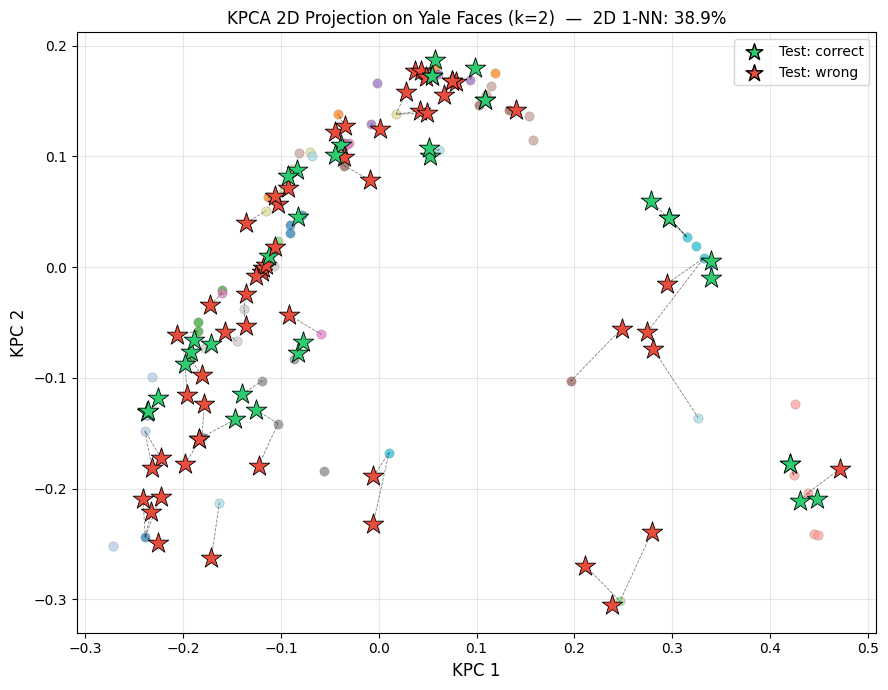

In [5]:
# ── 2D KPCA projection (k=2) with 1-NN matching (n_train=5) ──────────────────
Z2tr, Z2te = Ztr[:, :2], Zte[:, :2]
nn = np.argmin(cdist(Z2te, Z2tr), axis=1)        # nearest training neighbour in 2D
correct = y_tr[nn] == y_te
labels = sorted(persons_yale.keys())
palette = plt.cm.tab20(np.linspace(0, 1, len(labels)))
cof = {lab: palette[i] for i, lab in enumerate(labels)}

plt.figure(figsize=(9, 7))
for lab in labels:                                # training points coloured by person
    m = y_tr == lab
    plt.scatter(Z2tr[m, 0], Z2tr[m, 1], color=cof[lab], s=45, alpha=0.7,
                edgecolors='gray', linewidths=0.3)
for j in range(len(y_te)):                        # test stars + dashed 1-NN links
    plt.plot([Z2te[j, 0], Z2tr[nn[j], 0]], [Z2te[j, 1], Z2tr[nn[j], 1]],
             'k--', lw=0.6, alpha=0.5)
    plt.scatter(Z2te[j, 0], Z2te[j, 1], marker='*', s=240, zorder=5,
                color=('#2ecc71' if correct[j] else '#e74c3c'),
                edgecolors='black', linewidths=0.6)
plt.scatter([], [], marker='*', s=160, color='#2ecc71', edgecolors='black', label='Test: correct')
plt.scatter([], [], marker='*', s=160, color='#e74c3c', edgecolors='black', label='Test: wrong')
plt.xlabel("KPC 1", fontsize=12); plt.ylabel("KPC 2", fontsize=12)
plt.title(f"KPCA 2D Projection on Yale Faces (k=2)  —  2D 1-NN: {correct.mean()*100:.1f}%", fontsize=12)
plt.legend(loc='best'); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("figures/kpca_8efa2af2_0.png", dpi=110, bbox_inches='tight')
plt.show()


n_tr | test |  PCA (mean±std) | KPCA (mean±std)
--------------------------------------------------


   2 |  135 |  70.59 ± 3.22  |  70.56 ± 3.08


   3 |  120 |  73.92 ± 2.56  |  73.71 ± 2.77


   4 |  105 |  75.00 ± 3.04  |  74.86 ± 3.05


   5 |   90 |  76.28 ± 2.88  |  76.28 ± 3.03


   6 |   75 |  78.73 ± 3.44  |  78.67 ± 3.48


   7 |   60 |  79.83 ± 4.01  |  79.58 ± 4.18


   8 |   45 |  79.67 ± 4.46  |  79.44 ± 4.32


   9 |   30 |  79.83 ± 4.65  |  79.83 ± 4.65


  10 |   15 |  81.33 ± 6.86  |  81.33 ± 6.86


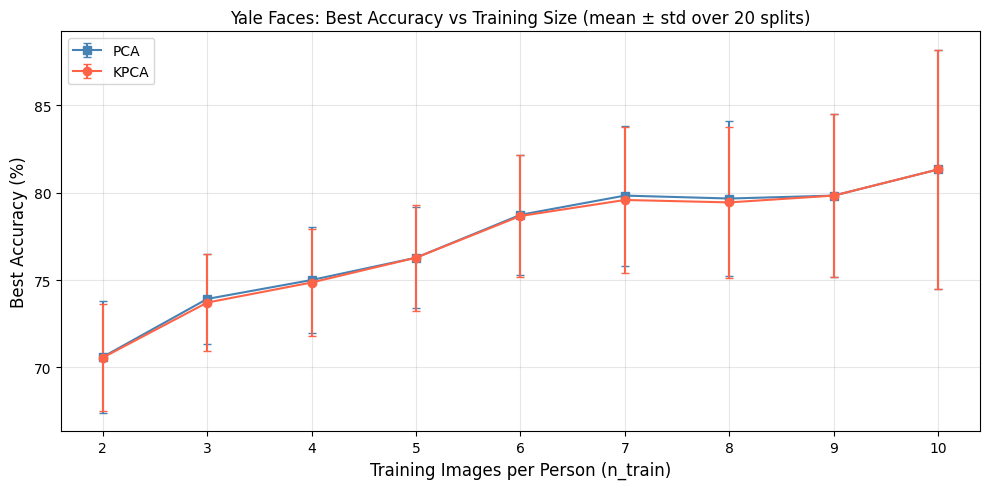


PCA and KPCA overlap within one standard deviation at every training size.


In [6]:
# ── Effect of training size: PCA vs KPCA over 20 random splits (mean ± std) ───
SEEDS = list(range(20))
n_tr_vals = list(range(2, 11))
pca_mean, pca_std, kp_mean, kp_std = [], [], [], []
print(f"{'n_tr':>4} | {'test':>4} | {'PCA (mean±std)':>15} | {'KPCA (mean±std)':>15}")
print("-" * 50)
for n_tr in n_tr_vals:
    ps, kps = [], []
    for s in SEEDS:
        Xt, yt, Xe, ye = split_yale(persons_yale, n_train=n_tr, seed=s)
        sig = auto_select_sigma(Xt, multiplier=5)
        Ztr_s, Zte_s = kpca_fit_project(Xt, Xe, sig)
        Ptr_s, Pte_s = pca_fit_project(Xt, Xe)
        # best over k (swept on test -> optimistic, but identical for both methods)
        kps.append(max(acc_at_k(Ztr_s, yt, Zte_s, ye, k) for k in range(1, Ztr_s.shape[1] + 1)))
        ps.append(max(acc_at_k(Ptr_s, yt, Pte_s, ye, k) for k in range(1, Ptr_s.shape[1] + 1)))
    pca_mean.append(np.mean(ps)); pca_std.append(np.std(ps))
    kp_mean.append(np.mean(kps)); kp_std.append(np.std(kps))
    print(f"{n_tr:>4} | {len(ye):>4} | {np.mean(ps):6.2f} ± {np.std(ps):4.2f}  | {np.mean(kps):6.2f} ± {np.std(kps):4.2f}")

pca_mean, pca_std = np.array(pca_mean), np.array(pca_std)
kp_mean, kp_std = np.array(kp_mean), np.array(kp_std)
plt.figure(figsize=(10, 5))
plt.errorbar(n_tr_vals, pca_mean, yerr=pca_std, fmt='s-', color='steelblue', capsize=3, label='PCA')
plt.errorbar(n_tr_vals, kp_mean, yerr=kp_std, fmt='o-', color='tomato', capsize=3, label='KPCA')
plt.xlabel("Training Images per Person (n_train)", fontsize=12)
plt.ylabel("Best Accuracy (%)", fontsize=12)
plt.title("Yale Faces: Best Accuracy vs Training Size (mean ± std over 20 splits)", fontsize=12)
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout()
plt.savefig("figures/kpca_b6b69353_0.png", dpi=110, bbox_inches='tight')
plt.show()
print("\nPCA and KPCA overlap within one standard deviation at every training size.")


Averaged over 20 splits, PCA and KPCA overlap within one standard deviation at every training size on Yale Faces. We next evaluate on the larger, more varied Extended Yale B dataset to see whether any difference emerges.

### PCA vs KPCA on Extended Yale B

The Extended Yale B dataset contains 28 subjects, each photographed under 576 illumination and pose conditions, totaling over 16,000 images. All images are cropped and resized to 168 x 192 pixels.

In [7]:
def load_yaleB(path):
    persons = {}
    for folder in sorted(os.listdir(path)):
        fp = os.path.join(path, folder)
        if os.path.isdir(fp) and folder.startswith('yaleB'):
            imgs = []
            for f in sorted(os.listdir(fp)):
                if f.endswith('.pgm'):
                    try:
                        imgs.append(np.array(Image.open(os.path.join(fp, f)), dtype=np.float64))
                    except Exception:
                        pass
            if imgs:
                persons[folder] = imgs
    return persons

def split_data(persons, n_train, n_test, seed=42):
    random.seed(seed)
    tr_imgs, tr_labels, te_imgs, te_labels = [], [], [], []
    for label, imgs in persons.items():
        indices = list(range(len(imgs)))
        random.shuffle(indices)
        for i in indices[:n_train]:
            tr_imgs.append(imgs[i]); tr_labels.append(label)
        for i in indices[n_train:n_train + n_test]:
            te_imgs.append(imgs[i]); te_labels.append(label)
    return (np.array([img.flatten() for img in tr_imgs]), np.array(tr_labels),
            np.array([img.flatten() for img in te_imgs]), np.array(te_labels))

persons = load_yaleB("Datasets/yaleB_extended")
print(f"Subjects: {len(persons)}")
print(f"Images per subject: {len(next(iter(persons.values())))}")
print(f"Image size: {next(iter(persons.values()))[0].shape}")
print(f"Feature dimension: {np.prod(next(iter(persons.values()))[0].shape)}")

# Split: 50 train, 10 test per person
n_train, n_test = 50, 10
X_train, y_train, X_test, y_test = split_data(persons, n_train, n_test)
print(f"\nTraining: {X_train.shape}, Test: {X_test.shape}")


Subjects: 28
Images per subject: 576
Image size: (168, 192)
Feature dimension: 32256



Training: (1400, 32256), Test: (280, 32256)


### Accuracy vs Number of Components

With `n_train = 50` per subject we sweep the number of components from 1 to 200 and compare 1-NN accuracy, averaged over **5 random splits** (mean ± std shading).

mean sigma (5x) = 23283,  seeds = 5,  test = 280/split
k=  1 | PCA   7.07 ± 1.34 | KPCA   8.36 ± 0.43
k=  2 | PCA  14.00 ± 1.83 | KPCA  14.21 ± 1.74
k=  5 | PCA  63.79 ± 2.05 | KPCA  65.00 ± 2.06
k= 10 | PCA  82.50 ± 3.33 | KPCA  82.21 ± 3.58
k= 20 | PCA  88.43 ± 2.23 | KPCA  88.29 ± 2.50
k= 30 | PCA  90.57 ± 1.67 | KPCA  90.21 ± 1.57
k= 50 | PCA  91.07 ± 1.43 | KPCA  90.93 ± 1.73
k= 80 | PCA  92.14 ± 1.34 | KPCA  91.93 ± 1.47
k=100 | PCA  92.14 ± 1.50 | KPCA  92.36 ± 1.71
k=150 | PCA  92.36 ± 1.31 | KPCA  92.14 ± 1.64
k=200 | PCA  92.57 ± 1.09 | KPCA  92.50 ± 1.15


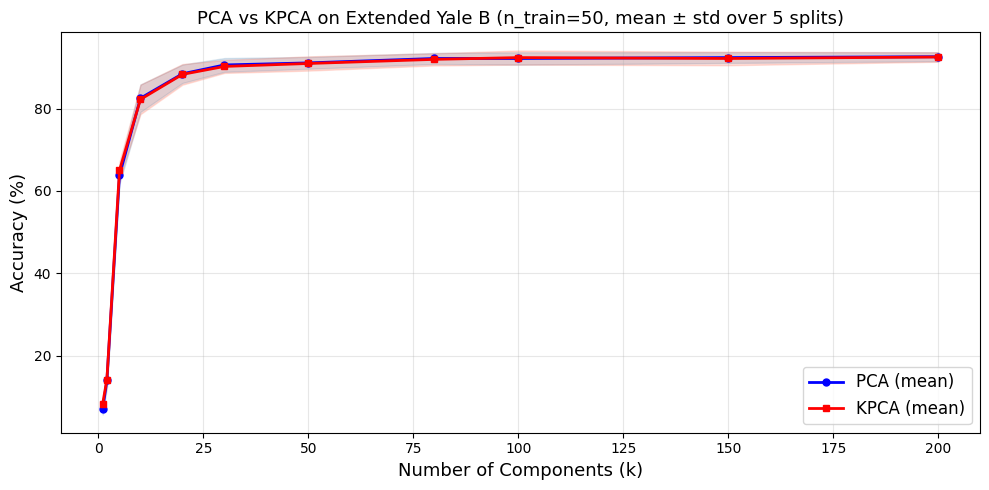


Best PCA:  92.57% at k=200
Best KPCA: 92.50% at k=200


In [8]:
# ── Extended Yale B (n_train=50): accuracy vs #components over 5 random splits ─
SEEDS = list(range(5))
k_list = [1, 2, 5, 10, 20, 30, 50, 80, 100, 150, 200]
pca_rows, kpca_rows, sigmas = [], [], []
for s in SEEDS:
    Xt, yt, Xe, ye = split_data(persons, 50, 10, seed=s)
    sig = auto_select_sigma(Xt, multiplier=5); sigmas.append(sig)
    Ztr_s, Zte_s = kpca_fit_project(Xt, Xe, sig)   # project once, then slice k
    Ptr_s, Pte_s = pca_fit_project(Xt, Xe)
    kpca_rows.append([acc_at_k(Ztr_s, yt, Zte_s, ye, k) for k in k_list])
    pca_rows.append([acc_at_k(Ptr_s, yt, Pte_s, ye, k) for k in k_list])

kp = np.array(kpca_rows); pc = np.array(pca_rows)
kp_m, kp_s, pc_m, pc_s = kp.mean(0), kp.std(0), pc.mean(0), pc.std(0)
print(f"mean sigma (5x) = {np.mean(sigmas):.0f},  seeds = {len(SEEDS)},  test = {len(ye)}/split")
for i, k in enumerate(k_list):
    print(f"k={k:>3d} | PCA {pc_m[i]:6.2f} ± {pc_s[i]:4.2f} | KPCA {kp_m[i]:6.2f} ± {kp_s[i]:4.2f}")

plt.figure(figsize=(10, 5))
plt.plot(k_list, pc_m, 'b-o', markersize=5, linewidth=2, label='PCA (mean)')
plt.fill_between(k_list, pc_m - pc_s, pc_m + pc_s, color='steelblue', alpha=0.2)
plt.plot(k_list, kp_m, 'r-s', markersize=5, linewidth=2, label='KPCA (mean)')
plt.fill_between(k_list, kp_m - kp_s, kp_m + kp_s, color='tomato', alpha=0.2)
plt.xlabel("Number of Components (k)", fontsize=13)
plt.ylabel("Accuracy (%)", fontsize=13)
plt.title("PCA vs KPCA on Extended Yale B (n_train=50, mean ± std over 5 splits)", fontsize=13)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("figures/pca_kpca_compare_k_0.png", dpi=110, bbox_inches='tight')
plt.show()

print(f"\nBest PCA:  {pc_m.max():.2f}% at k={k_list[pc_m.argmax()]}")
print(f"Best KPCA: {kp_m.max():.2f}% at k={k_list[kp_m.argmax()]}")


### Effect of Training Size

We vary the number of training images per subject from 5 to 80 and compare the best accuracy of each method, averaged over **5 random splits** with error bars (mean ± std).

n_train=  5 | PCA 65.29 ± 1.90 | KPCA 65.29 ± 1.74 | diff +0.00%


n_train= 10 | PCA 75.64 ± 2.56 | KPCA 75.79 ± 2.73 | diff +0.14%


n_train= 20 | PCA 84.64 ± 2.46 | KPCA 84.43 ± 2.38 | diff -0.21%


n_train= 30 | PCA 89.36 ± 0.89 | KPCA 89.21 ± 1.18 | diff -0.14%


n_train= 50 | PCA 92.64 ± 1.12 | KPCA 92.71 ± 1.29 | diff +0.07%


n_train= 80 | PCA 95.71 ± 0.98 | KPCA 95.64 ± 1.09 | diff -0.07%


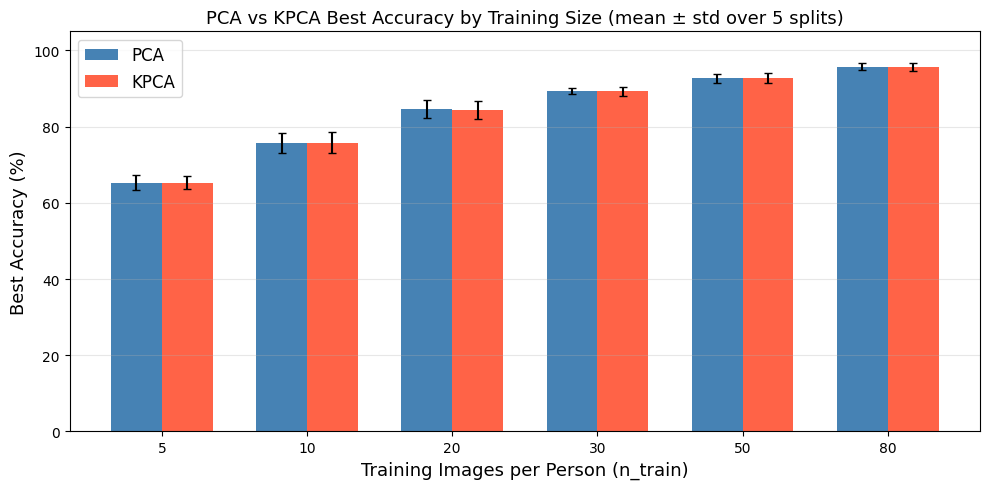

In [9]:
# ── Best accuracy by training size over 5 random splits (mean ± std) ──────────
SEEDS = list(range(5))
n_train_list = [5, 10, 20, 30, 50, 80]
best_pca_mean, best_pca_std, best_kpca_mean, best_kpca_std = [], [], [], []
for n_tr in n_train_list:
    kgrid = [5, 10, 20, 50, 100, min(200, n_tr * len(persons) - 1)]
    ps, kps = [], []
    for s in SEEDS:
        Xt, yt, Xe, ye = split_data(persons, n_tr, 10, seed=s)
        sig = auto_select_sigma(Xt, multiplier=5)
        Ztr_s, Zte_s = kpca_fit_project(Xt, Xe, sig)
        Ptr_s, Pte_s = pca_fit_project(Xt, Xe)
        ps.append(max(acc_at_k(Ptr_s, yt, Pte_s, ye, k) for k in kgrid))
        kps.append(max(acc_at_k(Ztr_s, yt, Zte_s, ye, k) for k in kgrid))
    best_pca_mean.append(np.mean(ps)); best_pca_std.append(np.std(ps))
    best_kpca_mean.append(np.mean(kps)); best_kpca_std.append(np.std(kps))
    print(f"n_train={n_tr:>3d} | PCA {np.mean(ps):5.2f} ± {np.std(ps):4.2f} | "
          f"KPCA {np.mean(kps):5.2f} ± {np.std(kps):4.2f} | diff {np.mean(kps)-np.mean(ps):+.2f}%")

best_pca_mean, best_pca_std = np.array(best_pca_mean), np.array(best_pca_std)
best_kpca_mean, best_kpca_std = np.array(best_kpca_mean), np.array(best_kpca_std)
plt.figure(figsize=(10, 5))
x = np.arange(len(n_train_list)); width = 0.35
plt.bar(x - width/2, best_pca_mean, width, yerr=best_pca_std, capsize=3, label='PCA', color='steelblue')
plt.bar(x + width/2, best_kpca_mean, width, yerr=best_kpca_std, capsize=3, label='KPCA', color='tomato')
plt.xticks(x, [str(n) for n in n_train_list])
plt.xlabel("Training Images per Person (n_train)", fontsize=13)
plt.ylabel("Best Accuracy (%)", fontsize=13)
plt.title("PCA vs KPCA Best Accuracy by Training Size (mean ± std over 5 splits)", fontsize=13)
plt.legend(fontsize=12)
plt.ylim(0, 105)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("figures/pca_kpca_compare_ntrain_0.png", dpi=110, bbox_inches='tight')
plt.show()


### Analysis

Both datasets use the 5x auto-sigma rule. With $\sigma$ this large the Gaussian kernel sits in a near-linear regime — for a nearest-neighbour pair $K(d_{NN}) \approx 0.98$ — so KPCA stays essentially on par with PCA. On Extended Yale B this large-$\sigma$ effect is compounded by the very high dimension-to-sample ratio, which already makes the data near-linearly separable.

To make the kernel's regime visible, we plot the kernel matrix at $\sigma = 1\times, 5\times, 10\times$ the mean nearest-neighbour distance: as the multiplier grows the off-diagonal contrast collapses and the kernel approaches a linear one — the regime in which KPCA reduces to PCA.

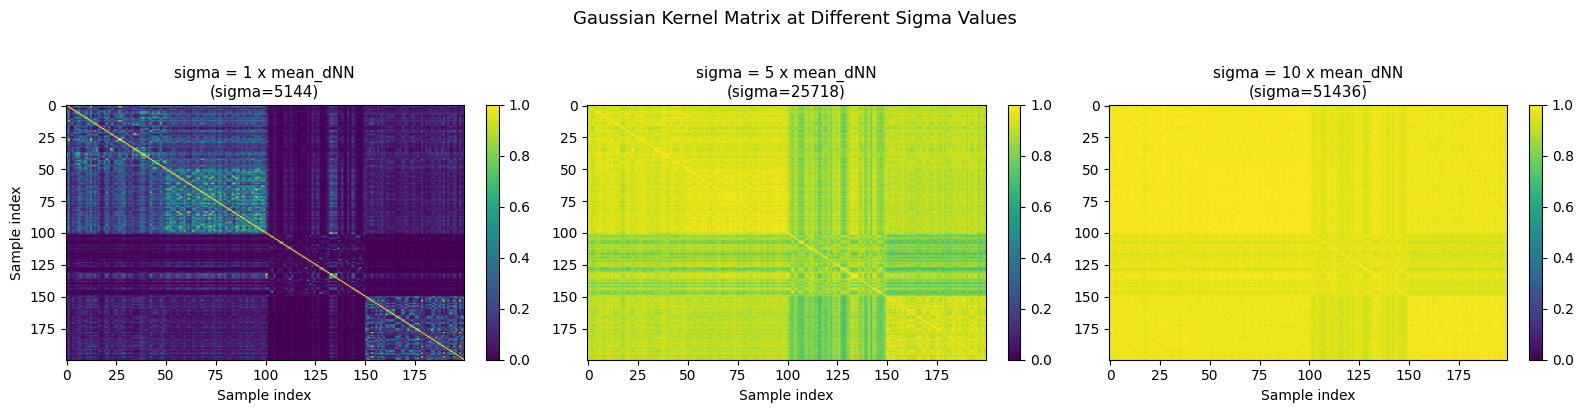

Feature dimension:     32256
Training samples:      1400
Dimension/Sample ratio: 23.0:1
Mean d_NN:             5144
Auto-sigma (5x):       25718

With sigma this large, exp(-d²/2σ²) ≈ 1 - d²/2σ² — that's a linear function.
The Gaussian kernel is barely doing anything nonlinear.
KPCA is essentially just PCA with extra steps.

For KPCA to actually help, you'd need:
  1. Much lower-dimensional features (not 32256d)
  2. Data with genuine nonlinear structure
  3. A smaller sigma that captures local geometry


In [10]:
# Kernel matrix visualization at different sigma values
D = cdist(X_train[:200], X_train[:200], metric='euclidean')  # subset for visualization
np.fill_diagonal(D, np.inf)
mean_dnn = np.mean(np.min(D, axis=1))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, mult in zip(axes, [1, 5, 10]):
    sig = mult * mean_dnn
    K = np.exp(-D**2 / (2 * sig**2))
    np.fill_diagonal(K, 1)
    im = ax.imshow(K, cmap='viridis', aspect='auto', vmin=0, vmax=1)
    ax.set_title(f"sigma = {mult} x mean_dNN\n(sigma={sig:.0f})", fontsize=11)
    ax.set_xlabel("Sample index")
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[0].set_ylabel("Sample index")
fig.suptitle("Gaussian Kernel Matrix at Different Sigma Values", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/pca_kpca_analysis_0.png", dpi=110, bbox_inches='tight')
plt.show()

# Dataset statistics
print(f"Feature dimension:     {X_train.shape[1]}")
print(f"Training samples:      {X_train.shape[0]}")
print(f"Dimension/Sample ratio: {X_train.shape[1] / X_train.shape[0]:.1f}:1")
print(f"Mean d_NN:             {mean_dnn:.0f}")
print(f"Auto-sigma (5x):       {5 * mean_dnn:.0f}")
print(f"\nWith sigma this large, exp(-d²/2σ²) ≈ 1 - d²/2σ² — that's a linear function.")
print(f"The Gaussian kernel is barely doing anything nonlinear.")
print(f"KPCA is essentially just PCA with extra steps.")
print(f"\nFor KPCA to actually help, you'd need:")
print(f"  1. Much lower-dimensional features (not {X_train.shape[1]}d)")
print(f"  2. Data with genuine nonlinear structure")
print(f"  3. A smaller sigma that captures local geometry")


### Summary

In [11]:
# Final comparison table (Extended Yale B, mean ± std over 5 random splits)
print("=" * 70)
print(f"{'n_train':>8} {'PCA':>17} {'KPCA':>17} {'|diff|':>10}")
print("-" * 70)
for i, n_tr in enumerate(n_train_list):
    d = abs(best_kpca_mean[i] - best_pca_mean[i])
    print(f"{n_tr:>8d}  {best_pca_mean[i]:6.2f} ± {best_pca_std[i]:4.2f}   "
          f"{best_kpca_mean[i]:6.2f} ± {best_kpca_std[i]:4.2f}   {d:7.2f}%")
print("-" * 70)

print()
print("Findings (5x auto-sigma rule, averaged over random splits):")
print("  Yale Faces:      PCA ~75.8% vs KPCA ~75.7% at n_train=5 (90 test imgs, 20 splits).")
print("  Extended Yale B: PCA and KPCA equal at every training size.")
print("  In every case |PCA - KPCA| is far below the seed-to-seed std, so any")
print("  gap is statistical noise rather than a real KPCA advantage.")


 n_train               PCA              KPCA     |diff|
----------------------------------------------------------------------
       5   65.29 ± 1.90    65.29 ± 1.74      0.00%
      10   75.64 ± 2.56    75.79 ± 2.73      0.14%
      20   84.64 ± 2.46    84.43 ± 2.38      0.21%
      30   89.36 ± 0.89    89.21 ± 1.18      0.14%
      50   92.64 ± 1.12    92.71 ± 1.29      0.07%
      80   95.71 ± 0.98    95.64 ± 1.09      0.07%
----------------------------------------------------------------------

Findings (5x auto-sigma rule, averaged over random splits):
  Yale Faces:      PCA ~75.8% vs KPCA ~75.7% at n_train=5 (90 test imgs, 20 splits).
  Extended Yale B: PCA and KPCA equal at every training size.
  In every case |PCA - KPCA| is far below the seed-to-seed std, so any
  gap is statistical noise rather than a real KPCA advantage.


### Removing the k-selection bias (validation-based model selection)

All results above report the *best* accuracy over a sweep of $k$, with $k$ chosen on the test set — an optimistic upper bound. As a final rigor check we add a **disjoint validation split**: the number of components $k^\*$ is chosen on validation and accuracy is reported on a separate test set (Yale: 5 train / 3 val / rest test; Extended Yale B: 50 train / 10 val / 10 test). We compare this honest estimate against the optimistic best-on-test to see (i) how large the selection bias is and (ii) whether PCA vs KPCA changes.

Validation-selected (honest) vs best-on-test (optimistic), mean ± std:

Yale (n_train=5),  test = 45/split
  PCA : honest 73.89 ± 6.04   optimistic 77.00 ± 4.62
  KPCA: honest 74.00 ± 5.67   optimistic 77.00 ± 4.78

Ext Yale B (n_train=50),  test = 280/split
  PCA : honest 93.64 ± 1.92   optimistic 94.00 ± 1.54
  KPCA: honest 93.36 ± 2.03   optimistic 93.93 ± 1.39


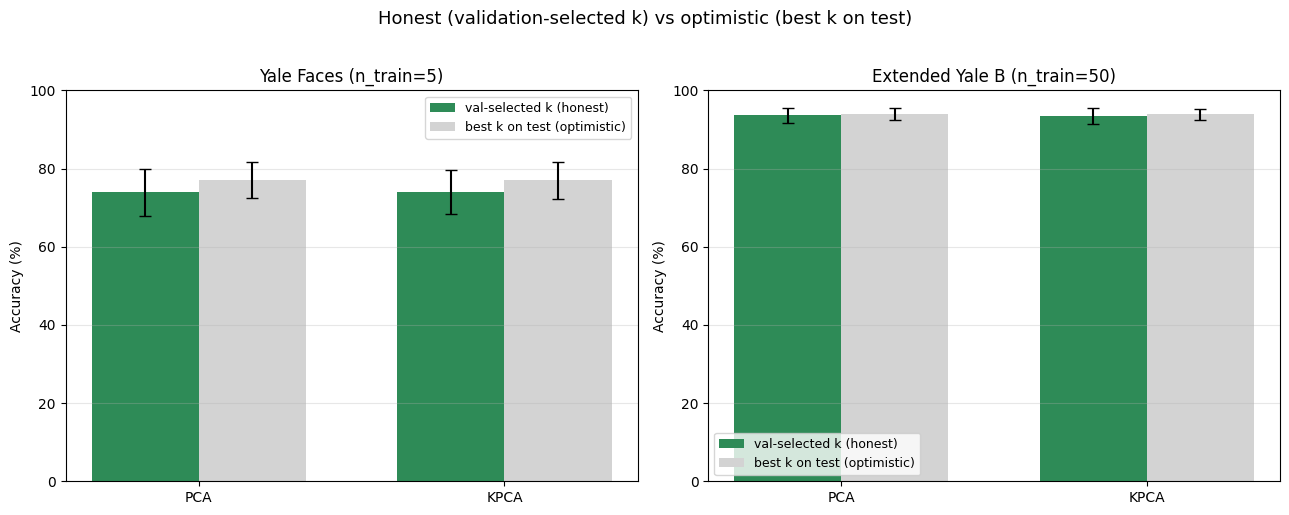

In [12]:
# ── Removing the k-selection bias: choose k on a validation set ───────────────
# Every "best accuracy" above swept k on the TEST set (optimistic). Here we add a
# disjoint validation split: k* is picked on validation, accuracy reported on
# test. We contrast this honest estimate with the optimistic best-on-test.

def _pca_sets(Xtr, Xv, Xte):
    mf = Xtr.mean(0); Xc = Xtr - mf; n = Xc.shape[0]
    cov = (Xc @ Xc.T) / (n - 1); ev, es = np.linalg.eigh(cov); es = es[:, np.argsort(ev)[::-1]]
    W = Xc.T @ es; W = W / np.linalg.norm(W, axis=0)
    return Xc @ W, (Xv - mf) @ W, (Xte - mf) @ W

def _kpca_sets(Xtr, Xv, Xte, sigma):
    K = gaussian_kernel(Xtr, Xtr, sigma); N = K.shape[0]; oN = np.ones((N, N)) / N
    Kc = K - oN @ K - K @ oN + oN @ K @ oN
    ev, ec = np.linalg.eigh(Kc); idx = np.argsort(ev)[::-1]; ev = ev[idx]; ec = ec[:, idx]
    pos = ev > 1e-10; ev = ev[pos]; ec = ec[:, pos]; al = ec / np.sqrt(ev)
    def proj(X):
        Kx = gaussian_kernel(X, Xtr, sigma); Nx = X.shape[0]; ox = np.ones((Nx, N)) / N
        return (Kx - ox @ K - Kx @ oN + ox @ K @ oN) @ al
    return Kc @ al, proj(Xv), proj(Xte)

def val_pick(Ztr, ytr, Zv, yv, Zte, yte, ks):
    """k* chosen on validation; return (honest test acc @k*, optimistic best-on-test)."""
    kstar = ks[int(np.argmax([acc_at_k(Ztr, ytr, Zv, yv, k) for k in ks]))]
    return acc_at_k(Ztr, ytr, Zte, yte, kstar), max(acc_at_k(Ztr, ytr, Zte, yte, k) for k in ks)

def split3(persons, n_tr, n_val, n_te, seed):
    """Disjoint train/val/test split; n_te=None -> all remaining images are test."""
    random.seed(seed); A, B, C, D, E, F = [], [], [], [], [], []
    for lab, imgs in persons.items():
        idx = list(range(len(imgs))); random.shuffle(idx)
        te = idx[n_tr + n_val:] if n_te is None else idx[n_tr + n_val:n_tr + n_val + n_te]
        for i in idx[:n_tr]:            A.append(imgs[i].flatten()); B.append(lab)
        for i in idx[n_tr:n_tr + n_val]: C.append(imgs[i].flatten()); D.append(lab)
        for i in te:                    E.append(imgs[i].flatten()); F.append(lab)
    return np.array(A), np.array(B), np.array(C), np.array(D), np.array(E), np.array(F)

def run_val_experiment(persons, n_tr, n_val, n_te, seeds, ks=None):
    r = {'PCA_val': [], 'PCA_opt': [], 'KPCA_val': [], 'KPCA_opt': []}
    for s in seeds:
        Xtr, ytr, Xv, yv, Xte, yte = split3(persons, n_tr, n_val, n_te, s)
        sig = auto_select_sigma(Xtr, multiplier=5)
        Ptr, Pv, Pte = _pca_sets(Xtr, Xv, Xte)
        Ztr, Zv, Zte = _kpca_sets(Xtr, Xv, Xte, sig)
        grid = ks or list(range(1, Ztr.shape[1] + 1))
        ph, po = val_pick(Ptr, ytr, Pv, yv, Pte, yte, [k for k in grid if k <= Ptr.shape[1]])
        kh, ko = val_pick(Ztr, ytr, Zv, yv, Zte, yte, [k for k in grid if k <= Ztr.shape[1]])
        r['PCA_val'].append(ph); r['PCA_opt'].append(po); r['KPCA_val'].append(kh); r['KPCA_opt'].append(ko)
    return {k: (np.mean(v), np.std(v)) for k, v in r.items()}, len(yte)

yale_res, yale_nte = run_val_experiment(persons_yale, 5, 3, None, list(range(20)))
yb_res, yb_nte = run_val_experiment(persons, 50, 10, 10, list(range(5)),
                                    ks=[1, 2, 5, 10, 20, 30, 50, 80, 100, 150, 200])

print("Validation-selected (honest) vs best-on-test (optimistic), mean ± std:")
for name, res, nte in [("Yale (n_train=5)", yale_res, yale_nte),
                       ("Ext Yale B (n_train=50)", yb_res, yb_nte)]:
    print(f"\n{name},  test = {nte}/split")
    print(f"  PCA : honest {res['PCA_val'][0]:5.2f} ± {res['PCA_val'][1]:4.2f}   "
          f"optimistic {res['PCA_opt'][0]:5.2f} ± {res['PCA_opt'][1]:4.2f}")
    print(f"  KPCA: honest {res['KPCA_val'][0]:5.2f} ± {res['KPCA_val'][1]:4.2f}   "
          f"optimistic {res['KPCA_opt'][0]:5.2f} ± {res['KPCA_opt'][1]:4.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, res) in zip(axes, [("Yale Faces (n_train=5)", yale_res),
                                  ("Extended Yale B (n_train=50)", yb_res)]):
    honest = [res['PCA_val'][0], res['KPCA_val'][0]]; honest_e = [res['PCA_val'][1], res['KPCA_val'][1]]
    optim = [res['PCA_opt'][0], res['KPCA_opt'][0]]; optim_e = [res['PCA_opt'][1], res['KPCA_opt'][1]]
    x = np.arange(2); w = 0.35
    ax.bar(x - w/2, honest, w, yerr=honest_e, capsize=4, label='val-selected k (honest)', color='seagreen')
    ax.bar(x + w/2, optim, w, yerr=optim_e, capsize=4, label='best k on test (optimistic)', color='lightgray')
    ax.set_xticks(x); ax.set_xticklabels(['PCA', 'KPCA'])
    ax.set_title(name, fontsize=12); ax.set_ylabel("Accuracy (%)")
    ax.set_ylim(0, 100); ax.grid(axis='y', alpha=0.3); ax.legend(fontsize=9)
plt.suptitle("Honest (validation-selected k) vs optimistic (best k on test)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("figures/val_selection_0.png", dpi=110, bbox_inches='tight')
plt.show()
